# Training and spatial readouts

This tutorial fits a `full` model and walks through the readouts that make scIToFlow more
than a velocity estimator:

- the inferred **spatial latent time**,
- the **niche factor** `h`,
- the **velocity field** projected to the tissue,
- a **within-model niche counterfactual** (the in-silico interrogation), and
- the optional **soft time prior**.

Everything runs on CPU with {func}`scitoflow.simulate_dataset`.

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from sklearn.neighbors import kneighbors_graph

torch.set_default_dtype(torch.float64)
torch.manual_seed(0)
np.random.seed(0)
plt.rcParams.update({"figure.dpi": 110, "font.size": 11})
NICHE_COLORS = ["#E69F00", "#56B4E9", "#009E73"]

from scitoflow import simulate_dataset, VAE, train_vae

adata = simulate_dataset(n_genes=60, grid=22, n_niches=3, seed=1)
x, y = adata.obs["x_position"].values, adata.obs["y_position"].values
coords = np.c_[x, y]
print(adata)

/home/bernaljp/micromamba/envs/scitoflow/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


AnnData object with n_obs × n_vars = 484 × 60
    obs: 'x_position', 'y_position', 'latent_time', 'stage', 'niche'
    layers: 'M_c', 'M_u', 'M_s', 'M_n', 'M_t'


## Train

A `full` model with the dual spatial + expression GraphSAGE niche encoder, for a modest
number of epochs.

In [2]:
model = VAE(
    observed=adata.n_vars, latent_dim=8, zr_dim=2, h_dim=2,
    encoder_hidden=20, decoder_hidden=20, t_encoder_hidden=20, graph_hidden=20,
    velocity_model_hidden=20, num_steps=30, ode_grid=30,
    topology="full", use_spatial=True, use_feedback=True,
    use_grid_ode=True, use_expr_gnn=True,
)
epochs, val_recon, val_traj, edge_spatial, adj_expr = train_vae(
    model=model, adata=adata, epochs=22, batch_size=128, learning_rate=5e-3,
    tangent_loss_params={"a": 1.0, "b": 10.0, "reg_lambda": 1.0},
    checkpoint_folder="/tmp/scitoflow_readouts",
)
print(f"final test reconstruction MSE: {val_recon[-1]:.3f}")

Warning, folder already exists. This may overwrite a previous fit.
Loading data and moving to GPU...
Successfully pre-loaded data to GPU.
Training on 436 cells, testing on 48 cells


Training Progress:   0%|          | 0/22 [00:00<?, ?epoch/s]

Training Progress:   0%|          | 0/22 [00:00<?, ?epoch/s, Batch Train Loss=2537.435, LR=5.0e-03]

Training Progress:   0%|          | 0/22 [00:00<?, ?epoch/s, Batch Train Loss=2490.689, LR=5.0e-03]

Training Progress:   0%|          | 0/22 [00:01<?, ?epoch/s, Batch Train Loss=2445.727, LR=5.0e-03]

...

Training Progress:  95%|█████████▌| 21/22 [00:29<00:01,  1.34s/epoch, Train=369.773, Test=350.346, Recon=89.058, Traj=159.035, LR=5.0e-03]

Training Progress: 100%|██████████| 22/22 [00:29<00:00,  1.35s/epoch, Train=369.773, Test=350.346, Recon=89.058, Traj=159.035, LR=5.0e-03]

Training Progress: 100%|██████████| 22/22 [00:29<00:00,  1.32s/epoch, Train=369.773, Test=350.346, Recon=89.058, Traj=159.035, LR=5.0e-03]

Epoch 21: Train Loss 369.773, Test Loss 350.346, Recon MSE 89.058, Traj MSE 159.035, Tangent Velo Loss 1.906
Loading best model at 21 epochs.
final test reconstruction MSE: 89.058



/home/bernaljp/Documents/scitoflow-public/scitoflow/training/train.py:266: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(


## Readouts

One call to {meth}`scitoflow.VAE.reconstruct_latent` returns the latent trajectory, the
latent velocity, the inferred latent time, and the niche factor for every spot.

In [3]:
model.eval()
data = {st: torch.tensor(adata.layers[model.topo.layer[st]].toarray(), dtype=torch.float64)
        for st in model.topo.states}
edge_expr = model._adj_to_edge_index(adj_expr.cpu())
with torch.no_grad():
    _, latent_full, velocity, latent_time, h = model.reconstruct_latent(
        data, edge_index_spatial=edge_spatial.cpu(), edge_index_expression=edge_expr)

t_inf = latent_time.cpu().numpy()
h = h.cpu().numpy()
rho = spearmanr(t_inf, adata.obs["latent_time"].values).statistic
print(f"Spearman(latent time, truth) = {rho:.3f} | niche factor h shape {h.shape}")

Spearman(latent time, truth) = 0.982 | niche factor h shape (484, 4)


### Latent time and the niche factor

The inferred latent time recovers the spatial gradient, and the components of the niche
factor `h` organize by spatial niche, which is what lets `h` condition the regulatory drift.

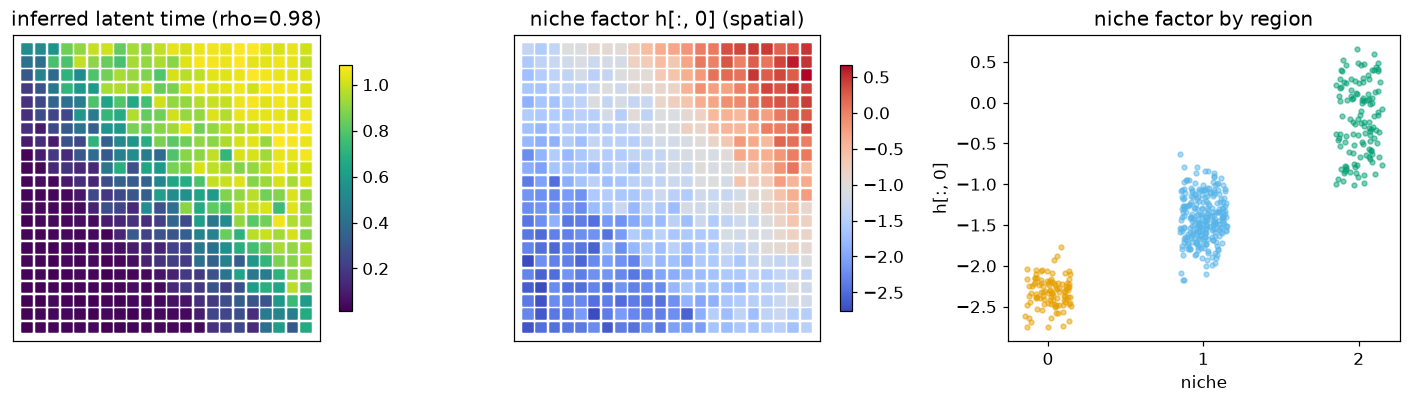

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
s0 = axes[0].scatter(x, y, c=t_inf, cmap="viridis", s=40, marker="s")
axes[0].set_title(f"inferred latent time (rho={rho:.2f})"); plt.colorbar(s0, ax=axes[0], shrink=0.8)

s1 = axes[1].scatter(x, y, c=h[:, 0], cmap="coolwarm", s=40, marker="s")
axes[1].set_title("niche factor h[:, 0] (spatial)"); plt.colorbar(s1, ax=axes[1], shrink=0.8)

niche = adata.obs["niche"].astype(int).values
for k in range(3):
    axes[2].scatter(np.full((niche == k).sum(), k) + np.random.uniform(-0.15, 0.15, (niche == k).sum()),
                    h[niche == k, 0], s=10, alpha=0.5, color=NICHE_COLORS[k])
axes[2].set_xticks([0, 1, 2]); axes[2].set_xlabel("niche"); axes[2].set_ylabel("h[:, 0]")
axes[2].set_title("niche factor by region")
for ax in axes[:2]:
    ax.set_aspect("equal"); ax.set_xticks([]); ax.set_yticks([])
fig.tight_layout()

### Velocity field on the tissue

{meth}`scitoflow.VAE.project_velocities` projects the latent velocities onto any embedding
through the learned tangent-space basis. Here we project onto the spatial coordinates and
draw streamlines with the package's plotting helper, colored by latent time.

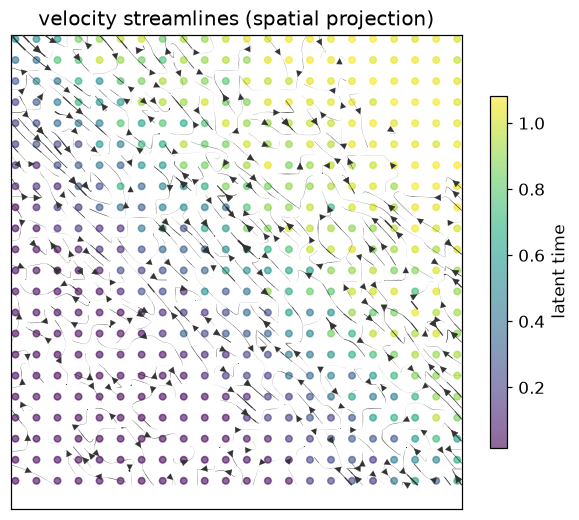

In [5]:
from scitoflow.plotting.velocity import plot_streamline_from_vectors

proj = torch.tensor(coords, dtype=torch.float64)
with torch.no_grad():
    v_emb = model.project_velocities(data, proj, edge_spatial.cpu(), adj_expr.cpu()).cpu().numpy()

fig, ax = plt.subplots(figsize=(5.5, 5))
plot_streamline_from_vectors(
    ax, X_emb=coords, V_emb=v_emb, color_points_by=t_inf, cmap="viridis",
    scatter_s=18, scatter_alpha=0.6, stream_density=1.4, stream_color="0.2",
    show_colorbar=True, colorbar_label="latent time",
)
ax.set_title("velocity streamlines (spatial projection)")
ax.set_aspect("equal"); ax.set_xticks([]); ax.set_yticks([])
fig.tight_layout()

## A within-model niche counterfactual

Because the drift is conditioned on the spatial factor, we can ask the fitted model a
counterfactual: *what would the inferred dynamics be if this spot had no spatial context?*
Setting `use_spatial=False` zeros the spatial half of `h` and we recompute the velocity.
The change measures how much the model's inferred regulation depends on the niche.

```{important}
This is a **within-model** dependence: it says the fitted model's regulation responds to
the spatial input, not that the tissue niche biologically causes the change. It is an
interrogation of the model, not an experiment.
```

median relative velocity change when the niche is ablated: 0.23


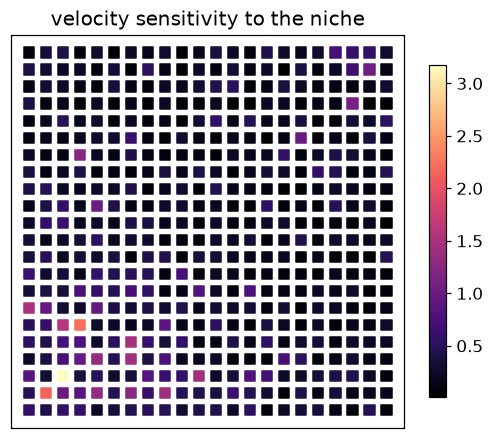

In [6]:
with torch.no_grad():
    model.use_spatial = True
    v_on = model.reconstruct_latent(data, edge_spatial.cpu(), edge_expr)[2].cpu().numpy()
    model.use_spatial = False
    v_off = model.reconstruct_latent(data, edge_spatial.cpu(), edge_expr)[2].cpu().numpy()
    model.use_spatial = True  # restore

rel_change = np.linalg.norm(v_on - v_off, axis=1) / (np.linalg.norm(v_on, axis=1) + 1e-8)
print(f"median relative velocity change when the niche is ablated: {np.median(rel_change):.2f}")

fig, ax = plt.subplots(figsize=(4.8, 4.2))
sc = ax.scatter(x, y, c=rel_change, cmap="magma", s=45, marker="s")
ax.set_title("velocity sensitivity to the niche"); plt.colorbar(sc, ax=ax, shrink=0.8)
ax.set_aspect("equal"); ax.set_xticks([]); ax.set_yticks([])
fig.tight_layout()

## The optional soft time prior

If you have a known time label (a developmental stage, or metabolic-labeling time) you can
softly supervise latent time. The prior is deliberately lag-tolerant: it nudges the
*ordering* rather than forcing every spot to `t = stage`, so asynchronous cells are allowed.
The example dataset carries a coarse, noisy `stage` label (0..4); we normalize it to [0, 1].

The prior matters most when latent time is **not yet resolved**. On this easy simulation a
long unsupervised fit already orders development well (the `rho = 0.98` above), so to see
the prior's effect we run a **controlled short fit**: two models from the *same
initialization* and data split, one with the prior and one without.

Loading data and moving to GPU...
Successfully pre-loaded data to GPU.
Training on 436 cells, testing on 48 cells


Training Progress:   0%|          | 0/8 [00:00<?, ?epoch/s]

Training Progress:   0%|          | 0/8 [00:00<?, ?epoch/s, Batch Train Loss=2537.435, LR=5.0e-03]

Training Progress:   0%|          | 0/8 [00:00<?, ?epoch/s, Batch Train Loss=2490.689, LR=5.0e-03]

Training Progress:   0%|          | 0/8 [00:01<?, ?epoch/s, Batch Train Loss=2445.727, LR=5.0e-03]

...

Training Progress:  88%|████████▊ | 7/8 [00:10<00:01,  1.35s/epoch, Train=705.158, Test=617.703, Recon=242.533, Traj=271.644, LR=5.0e-03]

Training Progress: 100%|██████████| 8/8 [00:10<00:00,  1.34s/epoch, Train=705.158, Test=617.703, Recon=242.533, Traj=271.644, LR=5.0e-03]

Training Progress: 100%|██████████| 8/8 [00:10<00:00,  1.30s/epoch, Train=705.158, Test=617.703, Recon=242.533, Traj=271.644, LR=5.0e-03]

Epoch 7: Train Loss 705.158, Test Loss 617.703, Recon MSE 242.533, Traj MSE 271.644, Tangent Velo Loss 3.994
Loading best model at 7 epochs.
short fit, Spearman(latent time, truth):  no prior = 0.524   soft prior = 0.844



/home/bernaljp/Documents/scitoflow-public/scitoflow/training/train.py:266: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(


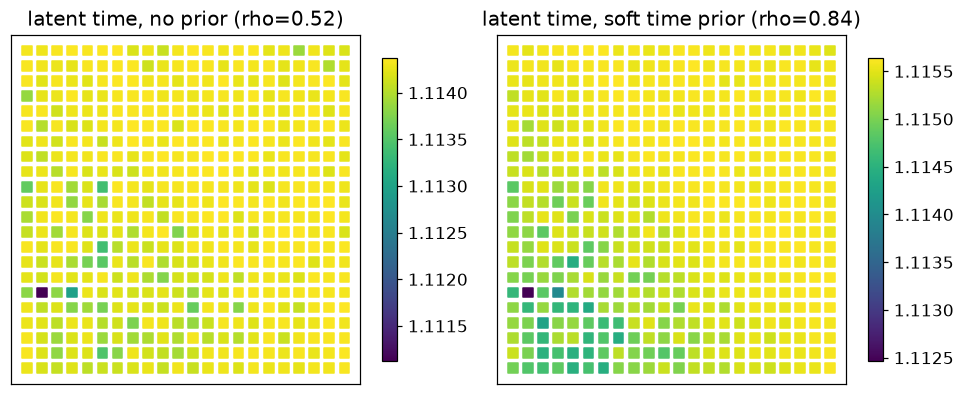

In [7]:
stage = adata.obs["stage"].values.astype(float)
tau = (stage - stage.min()) / (stage.max() - stage.min())
true_t = adata.obs["latent_time"].values

def short_fit(time_prior_weight, seed=0, epochs=8):
    torch.manual_seed(seed); np.random.seed(seed)
    m = VAE(observed=adata.n_vars, latent_dim=8, zr_dim=2, h_dim=2,
            encoder_hidden=20, decoder_hidden=20, t_encoder_hidden=20, graph_hidden=20,
            velocity_model_hidden=20, num_steps=30, ode_grid=30, topology="full",
            use_spatial=True, use_feedback=True, use_grid_ode=True, use_expr_gnn=True,
            time_prior_weight=time_prior_weight, time_prior_mode="soft")
    _, _, _, es, ae = train_vae(
        model=m, adata=adata, epochs=epochs, batch_size=128, learning_rate=5e-3,
        tangent_loss_params={"a": 1.0, "b": 10.0, "reg_lambda": 1.0},
        time_prior=(tau if time_prior_weight > 0 else None),
        checkpoint_folder=f"/tmp/scitoflow_tp_{time_prior_weight}")
    m.eval()
    with torch.no_grad():
        t = m.reconstruct_latent(data, es.cpu(), m._adj_to_edge_index(ae.cpu()))[3].cpu().numpy()
    return t

t_np = short_fit(0.0)     # no prior
t_tp = short_fit(3.0)     # soft prior

rho_np = abs(spearmanr(t_np, true_t).statistic)
rho_tp = abs(spearmanr(t_tp, true_t).statistic)
print(f"short fit, Spearman(latent time, truth):  no prior = {rho_np:.3f}   soft prior = {rho_tp:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(9, 3.8))
for ax, t, ttl in zip(axes, [t_np, t_tp], [f"no prior (rho={rho_np:.2f})",
                                           f"soft time prior (rho={rho_tp:.2f})"]):
    sc = ax.scatter(x, y, c=t, cmap="viridis", s=40, marker="s")
    ax.set_title(f"latent time, {ttl}"); ax.set_aspect("equal"); ax.set_xticks([]); ax.set_yticks([])
    plt.colorbar(sc, ax=ax, shrink=0.8)
fig.tight_layout()

With the short fit, the soft prior orders development that the unsupervised model has not
yet pinned down. Given a long fit this particular simulation is easy enough to resolve
either way; on real, noisier tissue the prior's anchoring is more valuable, and its
lag-tolerance keeps it from forcing a rigid `t = stage` correspondence.

## Summary

From one fit you get a spatial latent time, interpretable niche factors, a projectable
velocity field, and a perturbable model you can interrogate with counterfactuals. The time
prior lets you fold in known timing without over-constraining asynchronous development.

```{note}
These numbers come from a small simulation and will differ on real tissue. The point is the
**workflow and the readouts**, not the effect sizes.
```